In [3]:
import cv2
import numpy as np

# Load image
img = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)

def cv2_cleanup():
    cv2.waitKey()
    cv2.destroyAllWindows()

# --- FROM SCRATCH: Sampling & Quantization ---
# 1. Spatial Sampling (Downsampling by a factor of 2 by taking every 2nd pixel)
sampled_img = img[::2, ::2] 

# 2. Intensity Quantization (Reduce from 8-bit [0-255] to 3-bit [0-7] levels)
# Formula: quantized = (img / 2^(8-bits)) * 2^(8-bits) or bitwise shifting
bits_to_keep = 3
shift = 8 - bits_to_keep
quantized_scratch = (img >> shift) << shift

cv2.imshow("Original", img)
cv2_cleanup()

# --- WITH LIBRARY: OpenCV ---
# 1. Spatial Sampling (Resize using OpenCV)
height, width = img.shape[:2]
sampled_lib = cv2.resize(img, (width // 2, height // 2), interpolation=cv2.INTER_LINEAR)
cv2.imshow("Spatial", sampled_lib)
cv2_cleanup()

# 2. Quantization using OpenCV LUT (Look-Up Table)
# Create a mapping that reduces 256 levels down to 2^3 = 8 levels
levels = 2 ** bits_to_keep
factor = 256 / levels
lut = np.array([int(i / factor) * factor for i in range(256)], dtype=np.uint8)
quantized_lib = cv2.LUT(img, lut)

cv2.imshow("Quantized", quantized_lib)
cv2_cleanup()

In [4]:
import numpy as np

p1 = (2, 3)
p2 = (5, 7)

# --- FROM SCRATCH: Distance Formulas ---
# 1. Euclidean Distance: sqrt((x2-x1)^2 + (y2-y1)^2)
euclidean_dist = np.sqrt((p2[0] - p1[0])**2 + (p2[1] - p1[1])**2)

# 2. City-Block Distance (D4 / Manhattan): |x2 - x1| + |y2 - y1|
d4_dist = abs(p2[0] - p1[0]) + abs(p2[1] - p1[1])

# 3. Chessboard Distance (D8): max(|x2 - x1|, |y2 - y1|)
d8_dist = max(abs(p2[0] - p1[0]), abs(p2[1] - p1[1]))

print(f"Euclidean: {euclidean_dist}, Manhattan: {d4_dist}, Chebyshev: {d8_dist}")

Euclidean: 5.0, Manhattan: 7, Chebyshev: 4


In [8]:
import cv2
import numpy as np

img = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)

# --- FROM SCRATCH ---
# 1. Image Negation
neg_scratch = 255 - img
cv2.imshow("Negation", neg_scratch)
cv2_cleanup()

# 2. Log Transformation: s = c * log(1 + r)
c = 255 / np.log(1 + np.max(img))
log_scratch = c * np.log(1.0 + img.astype(np.float32))
log_scratch = np.array(log_scratch, dtype=np.uint8)
cv2.imshow("Log", log_scratch)
cv2_cleanup()

# 3. Contrast Stretching (Min-Max Normalization)
r_min, r_max = np.min(img), np.max(img)
contrast_scratch = ((img - r_min) / (r_max - r_min)) * 255
contrast_scratch = contrast_scratch.astype(np.uint8)
cv2.imshow("Contrast Stretching", contrast_scratch)
cv2_cleanup()

# --- WITH LIBRARY (OpenCV / NumPy) ---
# 1. Gamma Correction using OpenCV LUT
gamma = 2.0
inv_gamma = 1.0 / gamma
# Build standard look-up table for gamma mapping
table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)]).astype("uint8")
gamma_lib = cv2.LUT(img, table)
cv2.imshow("Gamma", gamma_lib)
cv2_cleanup()

# 2. Built-in Contrast Stretching / Normalization
normalized_lib = cv2.normalize(img, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
cv2.imshow("Contrast Stretching", normalized_lib)
cv2_cleanup()

C:\Users\kgliv\AppData\Local\Temp\ipykernel_9792\834382982.py:13: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(img))
C:\Users\kgliv\AppData\Local\Temp\ipykernel_9792\834382982.py:13: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(img))


In [9]:
import cv2
import numpy as np

img = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)

# --- FROM SCRATCH: Bit-Plane Slicing ---
# Extract each of the 8 bit planes
bit_planes = []
for i in range(8):
    # Extract the i-th bit and scale to 0-255 for display visibility
    plane = ((img >> i) & 1) * 255
    bit_planes.append(plane.astype(np.uint8))

# To view or save a specific bit plane (e.g., the most significant bit, index 7):
msb_plane = bit_planes[7]

cv2.imshow('MSB Bit Plane (Plane 7)', msb_plane)
cv2.waitKey(0)
cv2.destroyAllWindows()

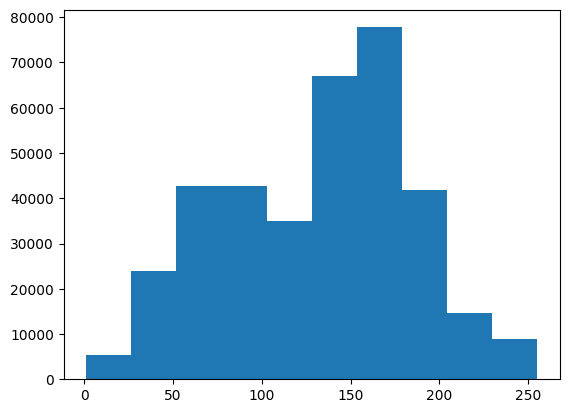

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

count, rnge = np.histogram(img.flatten(), bins=10)
plt.hist(img.flatten())
plt.show()

In [18]:
import cv2
import numpy as np

img = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)

# --- FROM SCRATCH: Mean Filter ---
def custom_mean_filter(image, kernel_size=3):
    pad = kernel_size // 2
    padded = np.pad(image, pad, mode='edge')
    h, w = image.shape
    out = np.zeros((h, w), dtype=np.float32)
    
    for i in range(h):
        for j in range(w):
            region = padded[i:i+kernel_size, j:j+kernel_size]
            out[i, j] = np.mean(region)
    return out.astype(np.uint8)

mean_scratch = custom_mean_filter(img, 3)

# --- WITH LIBRARY: OpenCV ---
mean_lib = cv2.blur(img, (3, 3))
cv2.imshow("Mean", mean_lib)
cv2_cleanup()

median_lib = cv2.medianBlur(img, 3)
cv2.imshow("Median", median_lib)
cv2_cleanup()

In [20]:
# --- FROM SCRATCH: Sobel X Gradient Manual Convolution ---
sobel_x_kernel = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
pad = 1
padded_img = np.pad(img, pad, mode='edge')
h, w = img.shape
edge_scratch = np.zeros((h, w), dtype=np.float32)

for i in range(h):
    for j in range(w):
        region = padded_img[i:i+3, j:j+3]
        edge_scratch[i, j] = np.sum(region * sobel_x_kernel)
edge_scratch = np.clip(edge_scratch, 0, 255).astype(np.uint8)

# --- WITH LIBRARY: OpenCV Edge Detection ---
sobel_lib = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
cv2.imshow("Sobel", sobel_lib)
cv2_cleanup()

laplacian_lib = cv2.Laplacian(img, cv2.CV_64F)
cv2.imshow("Laplacian", laplacian_lib)
cv2_cleanup()

In [23]:
# --- FROM SCRATCH: Image Scaling (Nearest Neighbor Interpolation) ---
def custom_scale(image, scale_factor=0.5):
    h, w = image.shape
    new_h, new_w = int(h * scale_factor), int(w * scale_factor)
    scaled = np.zeros((new_h, new_w), dtype=image.dtype)
    for i in range(new_h):
        for j in range(new_w):
            orig_i = int(i / scale_factor)
            orig_j = int(j / scale_factor)
            scaled[i, j] = image[orig_i, orig_j]
    return scaled

scaled_scratch = custom_scale(img, 0.5)

# --- WITH LIBRARY: OpenCV Transformations ---
h, w = img.shape[:2]
# Scaling
scaled_lib = cv2.resize(img, (0, 0), fx=0.5, fy=0.5)
cv2.imshow("Scaling", scaled_lib)
cv2_cleanup()

# Rotation (45 degrees around center)
M = cv2.getRotationMatrix2D((w/2, h/2), 45, 1.0)
rotated_lib = cv2.warpAffine(img, M, (w, h))
cv2.imshow("Rotation", rotated_lib)
cv2_cleanup()

# Alpha Blending (Image Addition with weights)
img2 = cv2.resize(img, (w, h))
alpha_blended = cv2.addWeighted(img, 0.6, img2, 0.4, 0)
cv2.imshow("Alpha Blending", alpha_blended)
cv2_cleanup()

In [27]:
# --- FROM SCRATCH ---
img1 = img
img2 = cv2.resize(img, (img.shape[1], img.shape[0]))

# Image Addition with safe overflow clipping
add_scratch = np.clip(img1.astype(np.int16) + img2.astype(np.int16), 0, 255).astype(np.uint8)
# Logical AND
logical_and_scratch = np.bitwise_and(img1, img2)

# --- WITH LIBRARY ---
add_lib = cv2.add(img1, img2)
cv2.imshow("Added", add_lib)
cv2_cleanup()

sub_lib = cv2.subtract(img1, img2)
cv2.imshow("Subtracted", sub_lib)
cv2_cleanup()

logical_and_lib = cv2.bitwise_and(img1, img2)
cv2.imshow("Logical AND", logical_and_lib)
cv2_cleanup()

In [29]:
# --- FROM SCRATCH: Global Thresholding ---
threshold_value = 127
thresh_scratch = np.zeros_like(img)
thresh_scratch[img > threshold_value] = 255

# --- WITH LIBRARY: OpenCV Thresholding & K-Means ---
_, thresh_lib = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
cv2.imshow("Thresholding", thresh_lib)
cv2_cleanup()

# K-Means Clustering Segmentation
Z = img.reshape((-1, 1)).astype(np.float32)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
_, labels, centers = cv2.kmeans(Z, 2, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
segmented_kmeans = centers[labels.flatten()].reshape(img.shape).astype(np.uint8)
cv2.imshow("KMeans", segmented_kmeans)
cv2_cleanup()

In [30]:
# --- FROM SCRATCH: Dilation (Max Filter using Structuring Element) ---
kernel = np.ones((3, 3), dtype=np.uint8)

def custom_dilation(image, kernel):
    h, w = image.shape
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    out = np.zeros_like(image)
    
    for i in range(h):
        for j in range(w):
            region = padded[i:i+kh, j:j+kw]
            # If structuring element matches, take the max in that region
            out[i, j] = np.max(region[kernel == 1])
    return out

dilated_scratch = custom_dilation(thresh_lib, kernel)

# --- WITH LIBRARY: OpenCV Morphology ---
dilated_lib = cv2.dilate(thresh_lib, kernel, iterations=1)
cv2.imshow("Dilated", dilated_lib)
cv2_cleanup()

eroded_lib = cv2.erode(thresh_lib, kernel, iterations=1)
cv2.imshow("Eroded", eroded_lib)
cv2_cleanup()